In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

import umap
import hdbscan
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA
from clustering.hdbscan_optimize import optimize_umap_hdbscan_n_components
from visualization.samples_plot import show_clustering_samples


PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")

n_samples = embedding.shape[0]

In [9]:
embedding_l2 = Normalizer(norm="l2").fit_transform(embedding)

pca_95 = PCA(n_components=0.95)
pca_95_embedding = pca_95.fit_transform(embedding_l2)

In [10]:
best = optimize_umap_hdbscan_n_components(
    pca_95_embedding,
    [10, 15, 20, 30, 40, 50],
    n_runs=20,
    min_clusters=5,
    max_clusters=8,
    max_noise=0.33,
    min_valid_run_ratio=0.70,
    min_mean_ari=0.70,
)

best_n_components = best["best_n_components"]

if best_n_components is None:
    raise ValueError("No suitable number of components found for UMAP.")

In [11]:
n_neighbors = int(
    np.clip(
        round(1.0 * np.sqrt(n_samples)),
        10,
        min(80, n_samples - 1),
    )
)
umap_embedding = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=0.05,
    n_components=best_n_components,
    metric="cosine",
).fit_transform(pca_95_embedding)

In [12]:
min_cluster_size = int(max(10, round(0.02 * n_samples)))
min_samples = int(np.clip(round(0.35 * min_cluster_size), 5, 20))

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    metric="euclidean",
)

labels = clusterer.fit_predict(umap_embedding)

probabilities = clusterer.probabilities_    # How much a points belong to the assigned cluster
outlier_scores = clusterer.outlier_scores_  # How much a point is anomalous compared to the rest of the data

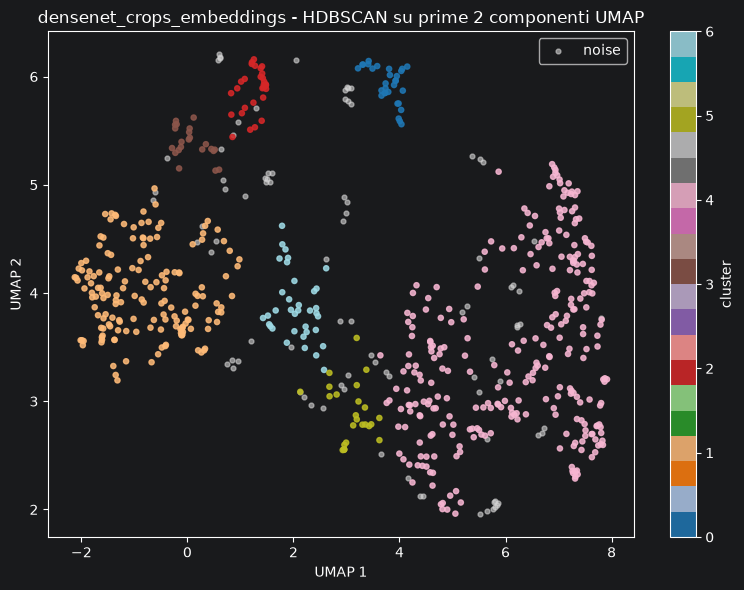

In [13]:
import matplotlib.pyplot as plt

umap_2d = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=0.05,
    n_components=2,
    metric="cosine",
).fit_transform(pca_95_embedding)

figure, axis = plt.subplots(figsize=(8, 6))

noise_mask = labels == -1
cluster_mask = ~noise_mask

axis.scatter(
    umap_2d[noise_mask, 0],
    umap_2d[noise_mask, 1],
    c="lightgray",
    s=12,
    alpha=0.6,
    label="noise",
)

scatter = axis.scatter(
    umap_2d[cluster_mask, 0],
    umap_2d[cluster_mask, 1],
    c=labels[cluster_mask],
    cmap="tab20",
    s=14,
    alpha=0.85,
)

axis.set_title(f"{EMBEDDING_NAME} - HDBSCAN su prime 2 componenti UMAP")
axis.set_xlabel("UMAP 1")
axis.set_ylabel("UMAP 2")
axis.legend(loc="best")
figure.colorbar(scatter, ax=axis, label="cluster")
figure.tight_layout()
plt.show()

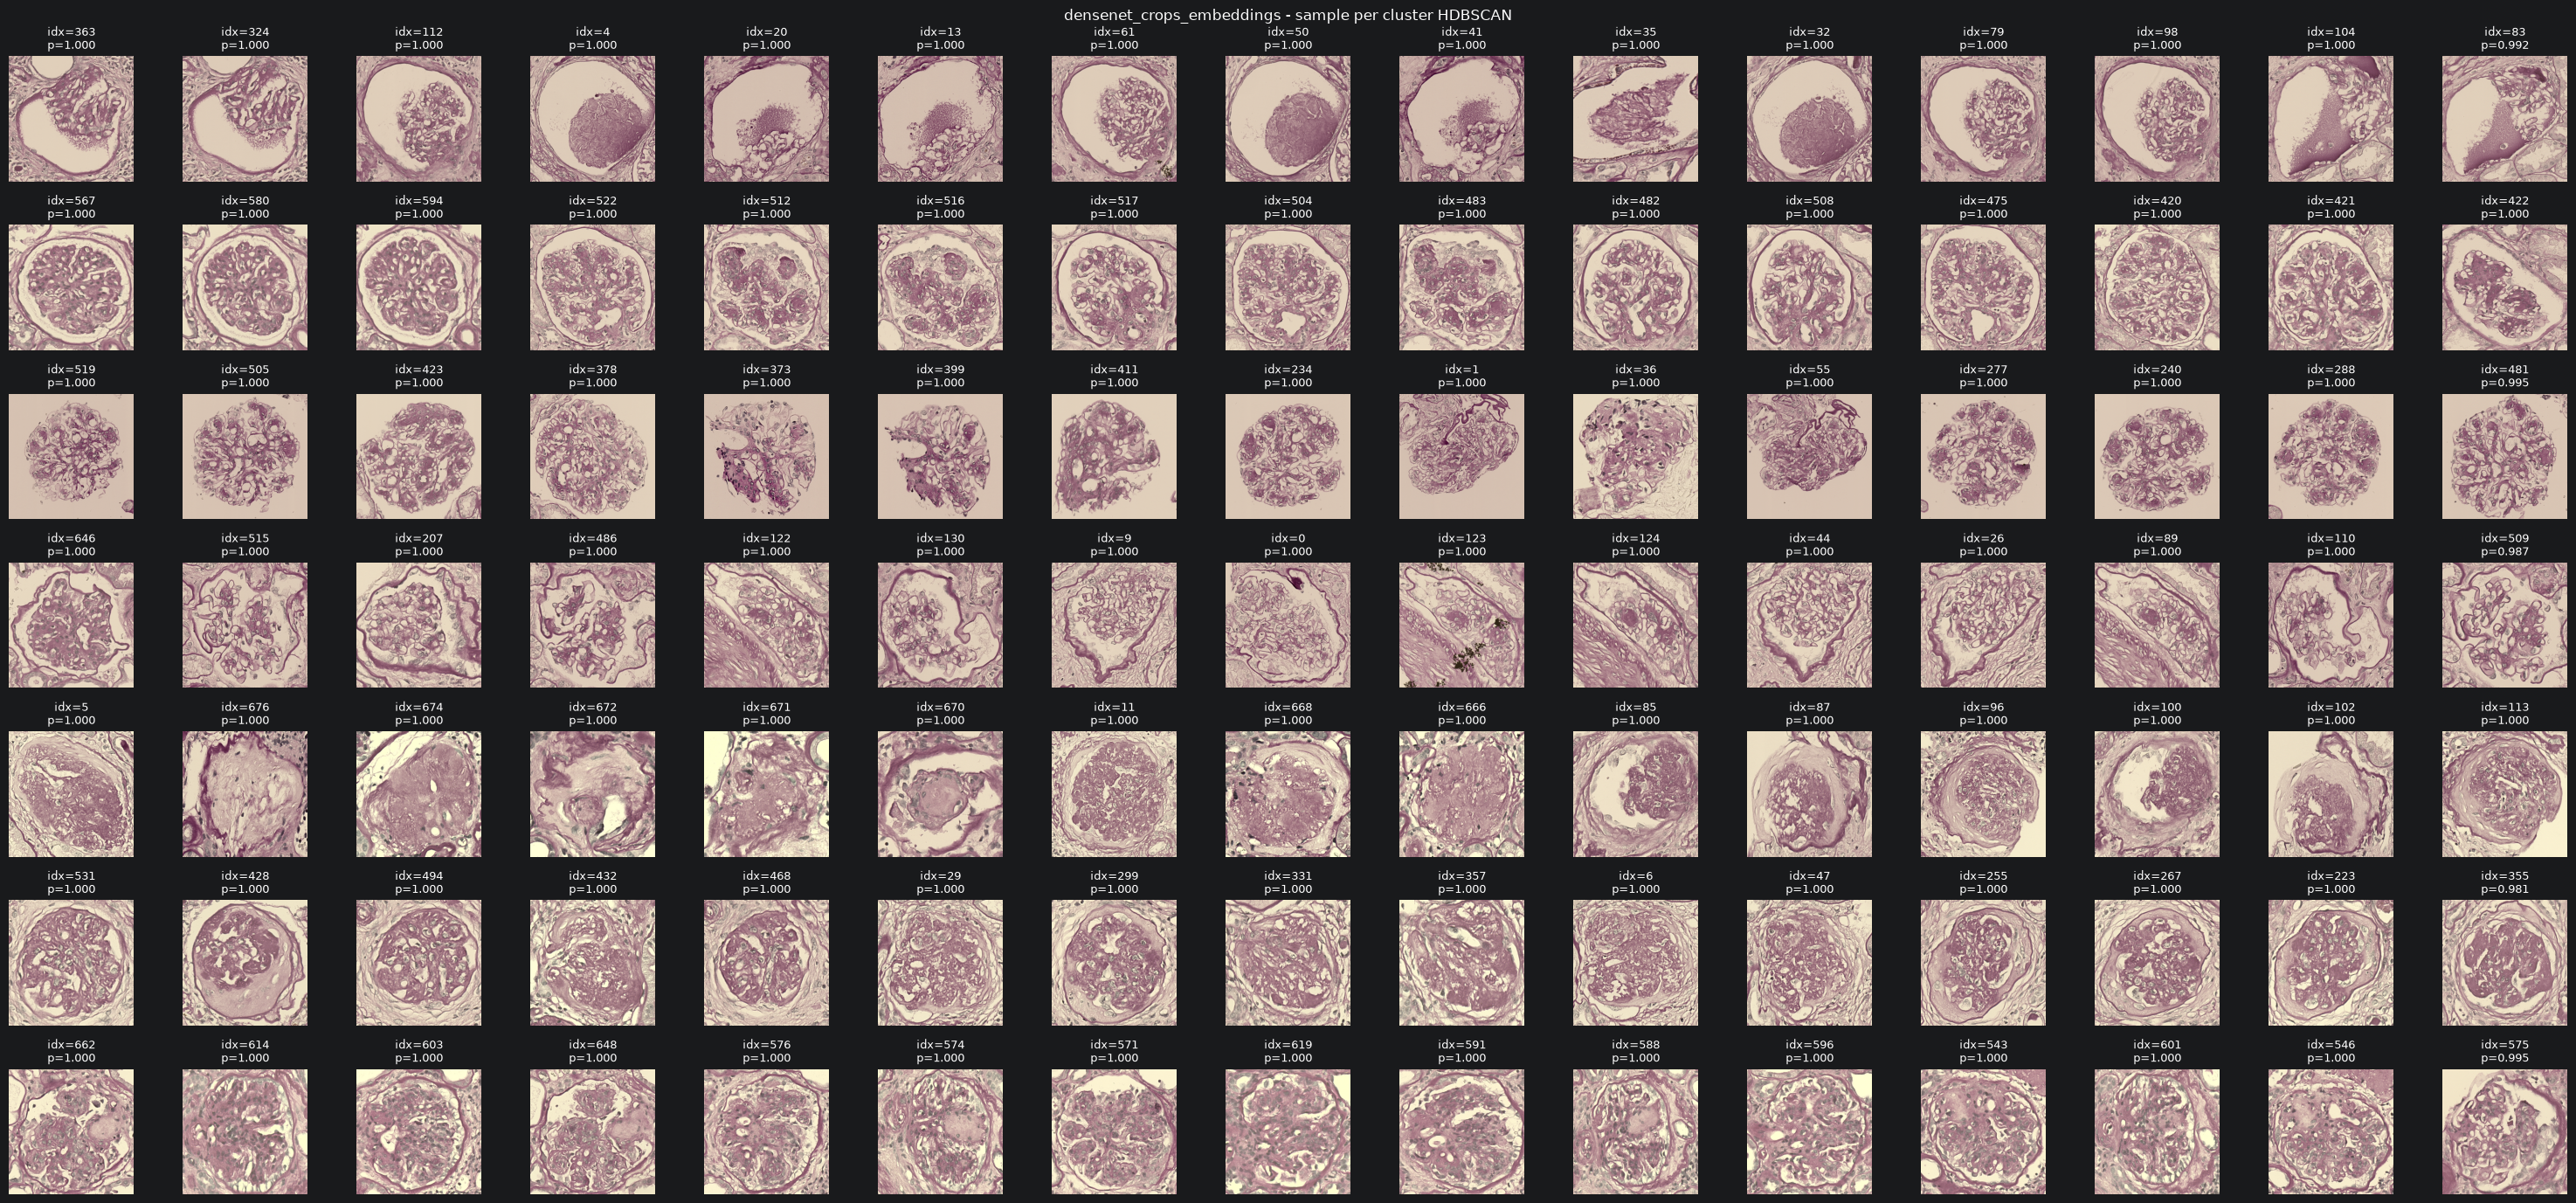

In [14]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=labels,
    probabilities=clusterer.probabilities_,
    image_paths=image_paths,
    x=15,
    include_noise=False,
    base_dir=PROJECT_ROOT,
    title=f"{EMBEDDING_NAME} - sample per cluster HDBSCAN",
    image_size=2.0,
    score_name="p",
    selection="highest_score",
)

In [15]:
cols = [
    "n_components",
    "successful_runs",
    "valid_runs",
    "valid_run_ratio",
    "mean_dbcv",
    "mean_ari",
    "mean_dbcv_all",
    "mean_ari_all",
    "mean_n_clusters_all",
    "mean_noise_ratio_all",
    "valid_for_selection",
]

print(best["results"][cols].sort_values("n_components"))

print(
    best["run_details"]
    .groupby(["n_components", "constraint_reason"])
    .size()
    .unstack(fill_value=0)
)

   n_components  successful_runs  valid_runs  valid_run_ratio  mean_dbcv  \
2            10               20          16             0.80   0.286987   
3            15               20          13             0.65   0.371760   
1            20               20          16             0.80   0.306804   
4            30               20          12             0.60   0.366195   
0            40               20          16             0.80   0.362875   
5            50               20          11             0.55   0.339242   

   mean_ari  mean_dbcv_all  mean_ari_all  mean_n_clusters_all  \
2  0.891465       0.292118      0.808061                 4.85   
3  0.859873       0.374317      0.883206                 4.95   
1  0.734409       0.316856      0.696296                 5.15   
4  0.871931       0.367793      0.684623                 5.15   
0  0.852770       0.354368      0.746971                 5.45   
5  0.727112       0.340924      0.641438                 4.65   

   mean_noi